# Imports

In [45]:
from nanopinv.sampler_jax import ParallelTemperingSampler
from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.utils import StatefulRNGKey
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import seaborn as sns
import gstools as gs

# for reloading submodules without restarting kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
sns.set_theme(context="notebook", style="whitegrid")
skey = StatefulRNGKey(0)

# Introduction

This notebook gives some hints in terms of how to approach the assignement and get to grips with the PINV package. 

Please note the PINV package is a not a finished package, it is still under development by T. Meier-Hansen so some variables and functions in the package are not finished or some parts are hard-coded in the source code. However, the package contains all the functions and variable settings needed to solve the assignment. It is highly recommended that you walk though the tutorial notebooks first, they are very much relevant, and you may well get stuck if you do not look at these first.

Additionally, it can be a good idea to look in the "sippi.pdf" file in literature folder, as it provides explanations of similar variables in the MATLAB version of the package and the naming convention has been kept the same. So a strategy for understanding a function or variable below could be (in prioritized order):
- Search for the function/variable name or slight variations in "sippi.pdf", "Hansen_etal_2013_SIPPI1.pdf" and "Hansen_etal_2013_SIPPI2.pdf". Read! 
- Experiment with a small number of iterations and see which effect different variables have
- Look into source code (search function in VScode is very helpful here), but keep in mind that this requires reading the code - it does not have a lot of comments. Specifically line 107-132 in ```extended_metropolis.py``` provides a bit of insight into what order things are called in.

Make sure you can run everything below and make some test diagnostic plots before you start to run a large number of iterations (this can take a long time!). Note that you can load the hdf5 files after the run has completed, so if you run the model and later want to look at results you can load them from the hdf5, instead of running everything again. 

# Load data

In [3]:
M = loadmat("data/BHRS_2D.mat")
data_obs = M["traveltimes"].squeeze()
data_std = M["traveltimes_std"].squeeze()
ndata, ndim = M["sources"].shape
sources = M["sources"].squeeze()
receivers = M["receivers"].squeeze()

dx = 0.25
dy = dx
min_x = np.min(M["sources"][:, 0])
max_x = np.max(M["receivers"][:, 0])
min_y = np.min(np.hstack((M["sources"][:, 1], M["receivers"][:, 1])))
max_y = np.max(np.hstack((M["sources"][:, 1], M["receivers"][:, 1])))


In [4]:
# M["sources"]
M

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Apr 29 13:02:47 2014',
 '__version__': '1.0',
 '__globals__': [],
 'sources': array([[ 9990.51      ,   832.012     ,     0.        ],
        [ 9990.51      ,   832.012     ,     0.        ],
        [ 9990.51      ,   832.012     ,     0.        ],
        ...,
        [10000.36826338,   832.29      ,     0.        ],
        [10000.36826338,   832.29      ,     0.        ],
        [10000.36826338,   832.29      ,     0.        ]], shape=(758, 3)),
 'receivers': array([[10000.37756955,   831.79      ,     0.        ],
        [10000.37277471,   832.04      ,     0.        ],
        [10000.36826338,   832.29      ,     0.        ],
        ...,
        [ 9990.59574812,   834.76      ,     0.        ],
        [ 9990.60331144,   835.01      ,     0.        ],
        [ 9990.61115827,   835.26      ,     0.        ]], shape=(758, 3)),
 'traveltimes': array([[114.4],
        [114.4],
        [115.2],
        [114.

In [5]:
M_prior = loadmat("data/BHRS_prior.mat")
M_prior.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x', 'y', 'prior_0', 'prior_1', 'prior_2'])

In [6]:
model = gs.Exponential(dim=2)
# fit = model.fit_variogram()

prior_data_pos = (M_prior["x"].squeeze(), M_prior["y"].squeeze())
prior_data_samples = [
    M_prior["prior_0"],
    M_prior["prior_1"],
    M_prior["prior_2"],
]

est_out = gs.vario_estimate(prior_data_pos, prior_data_samples, mesh_type="structured")

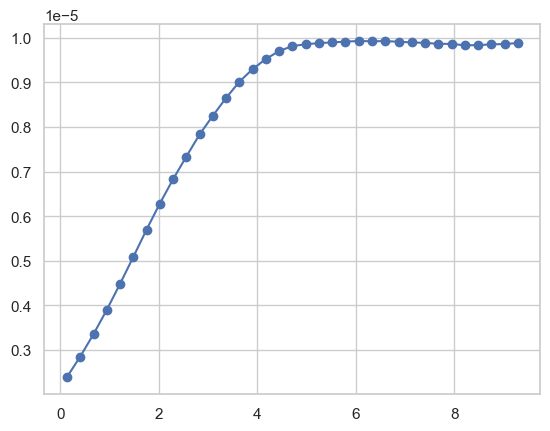

In [7]:
bin_centers_est, vario_est = est_out
plt.plot(bin_centers_est, vario_est, "o-", label="estimated variogram")

Looks a little bit like spherical:

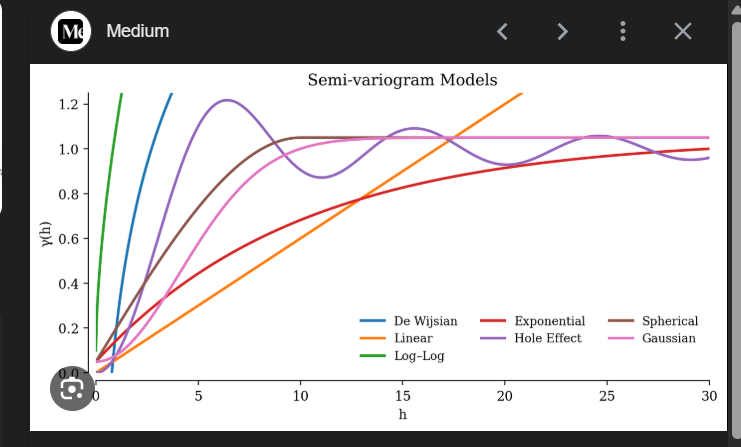

{'var': np.float64(8.062794673106892e-06), 'len_scale': np.float64(5.161389839419544), 'nugget': np.float64(1.8293390733792266e-06)}


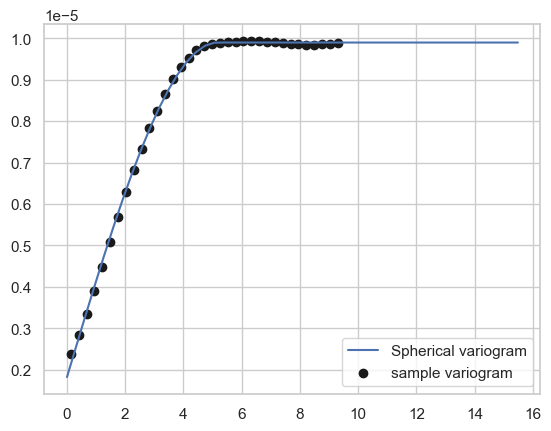

In [8]:
sph_model = gs.Spherical(dim=2)
model.set_arg_bounds(nugget=(0, 1e-3))
results, pcov = sph_model.fit_variogram(bin_centers_est, vario_est, curve_fit_kwargs={"gtol": 1e-14})

ax = sph_model.plot()
ax.scatter(bin_centers_est, vario_est, color="k", label="sample variogram")
ax.legend()

print(results)

In [9]:
models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}
scores = {}

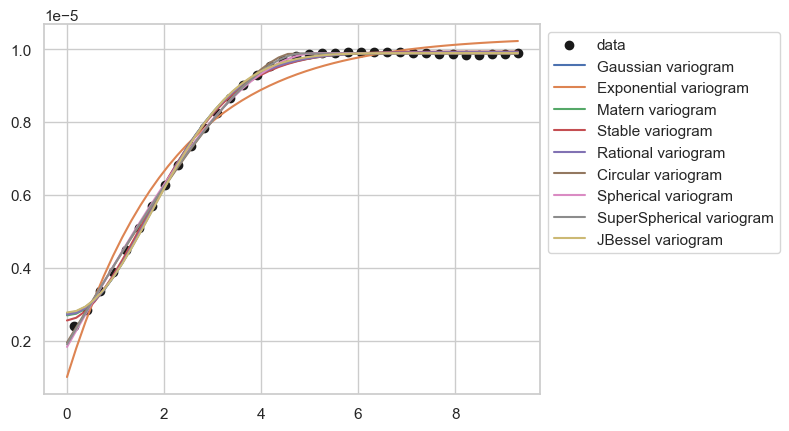

In [10]:
# plot the estimated variogram
plt.scatter(bin_centers_est, vario_est, color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
for model in models:
    fit_model = models[model](dim=2)
    para, pcov, r2 = fit_model.fit_variogram(bin_centers_est, vario_est, return_r2=True, curve_fit_kwargs={"gtol": 1e-14})
    fit_model.plot(x_max=np.max(bin_centers_est), ax=ax)
    scores[model] = r2

plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

In [11]:
ranking = sorted(scores.items(), key=lambda item: item[1], reverse=True)
print("RANKING by Pseudo-r2 score")
for i, (model, score) in enumerate(ranking, 1):
    print(f"{i:>6}. {model:>15}: {score:.5}")

plt.show()

RANKING by Pseudo-r2 score
     1.  SuperSpherical: 0.99944
     2.        Circular: 0.9994
     3.       Spherical: 0.9992
     4.          Stable: 0.99862
     5.          Matern: 0.99804
     6.        Rational: 0.99798
     7.        Gaussian: 0.99789
     8.         JBessel: 0.9978
     9.     Exponential: 0.97704


In [12]:
# We pick spherical as this is more standard choice and works well here
chosen_cov_model = gs.Spherical(dim=2)
results_cov_model, _ = chosen_cov_model.fit_variogram(bin_centers_est, vario_est, curve_fit_kwargs={"gtol": 1e-14})
print(results_cov_model)
assert chosen_cov_model.var == results_cov_model["var"]  # Sanity check that model has been updated

cov_matrix = chosen_cov_model.cov_spatial(prior_data_pos)
# plt.imshow(cov_matrix, cmap="viridis")
# prior_data_pos[0].shape
cov_matrix.shape

{'var': np.float64(8.062794673106892e-06), 'len_scale': np.float64(5.161389839419544), 'nugget': np.float64(1.8293390733792266e-06)}


(321,)

In [ ]:
import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
import gstools as gs

# Assuming prior_data_pos is a list/tuple of 1D arrays for the x and y axes: [x_coords, y_coords]
x_coords, y_coords = prior_data_pos

# 1. Generate the full Cartesian grid of shape (321, 321)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

# Flatten the grid to get all N = 321^2 points.
# pos shape will be (103041, 2)
pos = np.stack((X.ravel(), Y.ravel())).T

# 2. Build the KD-Tree with the flattened grid points
tree = cKDTree(pos)

# 3. Compute sparse distance matrix
max_dist = chosen_cov_model.len_scale
sparse_dist = tree.sparse_distance_matrix(
    tree,
    max_distance=max_dist,
    output_type='coo_matrix'
)

# 4. Apply covariance function to non-zero entries (including d=0 pairs explicitly kept by COO)
sparse_cov = sparse_dist.copy()
sparse_cov.data = chosen_cov_model.covariance(sparse_dist.data)

sparse_cov = sparse_cov.tocsr()

print(f"Number of spatial points (N): {pos.shape[0]}")
print(f"Matrix shape: {sparse_cov.shape}")
print(f"Non-zero elements: {sparse_cov.nnz}")


MemoryError: std::bad_alloc

In [15]:
import scipy.linalg as la

L = la.cholesky(sparse_cov, lower=True)

sparse_cov
# MultivariateNormalCholesky.from_cholesky(
#     shape=(len(prior_data_pos[0]), len(prior_data_pos[1])),
#     mean=np.mean(np.asarray(prior_data_samples).flatten(), axis=0),
#     cov=sparse_cov
# )

ValueError: setting an array element with a sequence.

In [ ]:
np.stack(prior_data_pos).T.shape

(321, 2)

In [ ]:
from scipy.spatial.distance import pdist, squareform

K = 100
x = np.linspace(0, 20, K)
y = x

# 2. Reconstruct the 2D grid and flatten into coordinates
X, Y = np.meshgrid(x, y, indexing='ij')

# Stack into an N x 2 array
coords = np.column_stack((X.flatten(), Y.flatten()))

# 3. Compute the dense pairwise Euclidean distance matrix
# dist_matrix is an N x N array of scalar distances h
dist_matrix = squareform(pdist(coords, metric='euclidean'))

# 4. Evaluate the covariance matrix
# model.covariance applies the theoretical function element-wise to the distances
cov_matrix = chosen_cov_model.covariance(dist_matrix)

# For numerical stability in inverse problems, explicitly ensure symmetry
# cov_matrix = 0.5 * (cov_matrix + cov_matrix.T)




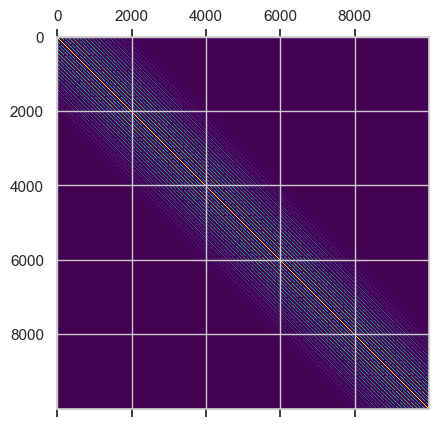

In [84]:
plt.matshow(cov_matrix, cmap="viridis")

In [114]:
L = la.cholesky(cov_matrix, lower=True)


In [115]:
dist = MultivariateNormalCholesky.from_covariance(
    shape=(K, K),
    mean=np.mean(np.asarray(prior_data_samples).flatten(), axis=0),
    cov=cov_matrix
)

In [116]:
small_x, small_y = x, y

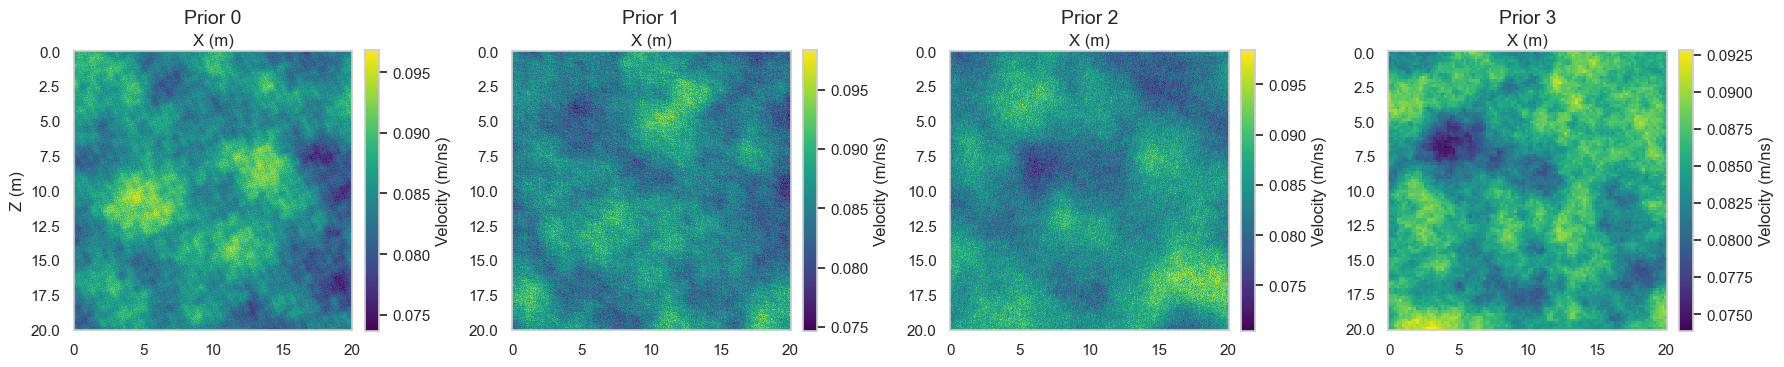

In [133]:

import matplotlib.pyplot as plt

# Extract spatial coordinates (squeeze removes any extra dimensions from MATLAB format)
x = M_prior['x'].squeeze()
y = M_prior['y'].squeeze()

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

prior_keys = ['prior_0', 'prior_1', 'prior_2']

for i, ax in enumerate(axes):
    if i == 3:
        # For the 4th subplot, we can plot the covariance matrix
        prior_data = dist(skey())
        x, y = small_x, small_y  # Use the smaller grid for the covariance plot
    else:
        # Extract the prior data matrix
        prior_data = M_prior[prior_keys[i]].squeeze()
        x, y = M_prior['x'].squeeze(), M_prior['y'].squeeze()  # Use the original grid for the prior plots


    # Plot using pcolormesh
    im = ax.pcolormesh(x, y, prior_data, shading='auto', cmap='viridis')

    # Formatting to match standard geophysical depth plots
    ax.set_aspect("equal")
    ax.invert_yaxis() # Usually 'y' represents depth, so we invert it
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Prior {i}", pad=20, fontsize=14)
    ax.set_xlabel("X (m)")

    if i == 0:
        ax.set_ylabel("Z (m)")

    # Add a colorbar for each subplot
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Velocity (m/ns)")

plt.tight_layout()
plt.show()

array([[8.06279467e-06, 7.85570294e-06, 7.64873269e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.85570294e-06, 8.06279467e-06, 7.85570294e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.64873269e-06, 7.85570294e-06, 8.06279467e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        8.06279467e-06, 7.85570294e-06, 7.64873269e-06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.85570294e-06, 8.06279467e-06, 7.85570294e-06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.64873269e-06, 7.85570294e-06, 8.06279467e-06]], shape=(321, 321))

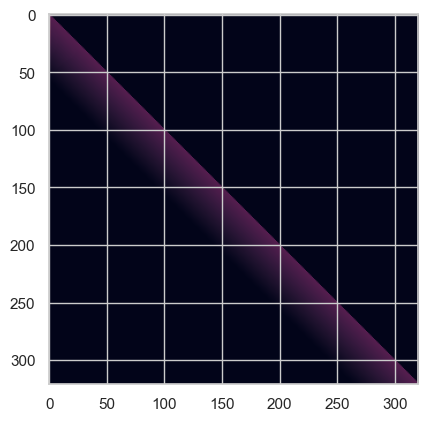

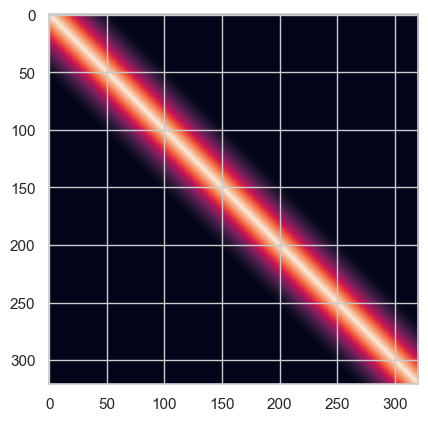

In [38]:
from sksparse.cholmod import cholesky
L, _ = cholesky(sparse_cov, lower=True, order="natural")
x = L.todense()
plt.imshow(x)

plt.figure()
A = x @ x.T
plt.imshow(A)
A

In [56]:
shape = (len(prior_data_pos[0]), len(prior_data_pos[1]))
mean = np.mean(np.asarray(prior_data_samples).flatten(), axis=0)
dist = MultivariateNormalCholesky(L=x, mean=float(mean), shape=shape)

# dist(skey())
shape

(321, 321)

In [ ]:
help(cholesky)

Help on method descriptor cholesky in module sksparse.cholmod:

cholesky(A, beta=0, mode='auto', ordering_method='default', use_long=None)
    Computes the fill-reducing Cholesky decomposition of

      .. math:: A + \beta I

    where ``A`` is a sparse, symmetric, positive-definite matrix, preferably
    in CSC format, and ``beta`` is any real scalar (usually 0 or 1). (And
    :math:`I` denotes the identity matrix.)

    Only the lower triangular part of ``A`` is used.

    ``mode`` is passed to :func:`analyze`.

    ``ordering_method`` is passed to :func:`analyze`.

    ``use_long`` is passed to :func:`analyze`.

    :returns: A :class:`Factor` object represented the decomposition.



In [ ]:
# import numpy as np
# from scipy.interpolate import interp1d
# from scipy.spatial.distance import pdist, squareform

# # 1. Unpack the output from gstools ensemble estimate
# bin_centers, emp_vario = est_out

# # 2. Approximate the sill ($σ^2$)
# # We use the maximum value of the empirical ensemble variogram as the sill.
# sill = np.max(emp_vario)

# # 3. Convert empirical semi-variogram to covariance: $C(h) = σ^2 - γ(h)$
# c_emp = sill - emp_vario

# # Ensure the zero-lag bin is explicitly defined for the interpolation
# if bin_centers[0] != 0:
#     h_vals = np.insert(bin_centers, 0, 0.0)
#     c_vals = np.insert(c_emp, 0, sill)
# else:
#     h_vals = bin_centers
#     c_vals = c_emp

# # 4. Construct the interpolation function
# # Bounds:
# # - Distances < min(h_vals) extrapolate to the sill.
# # - Distances > max(h_vals) extrapolate to 0 covariance.
# cov_interpolant = interp1d(
#     h_vals,
#     c_vals,
#     kind='linear',
#     bounds_error=False,
#     fill_value=(sill, 0.0)
# )

# # 5. Reconstruct the 2D grid to compute the pairwise distance matrix
# # Since mesh_type="structured", we create the full grid from the 1D axes.
# X, Y = np.meshgrid(M_prior["x"], M_prior["y"], indexing='ij')

# # Stack coordinates into an (N, 2) array where N = len(x) * len(y)
# coords = np.column_stack((X.flatten(), Y.flatten()))

# # Compute the dense N x N Euclidean distance matrix
# dist_matrix = squareform(pdist(coords, metric='euclidean'))

# # 6. Evaluate the interpolant to build the covariance matrix $Σ$
# cov_matrix = cov_interpolant(dist_matrix)

# # Enforce the exact total variance on the main diagonal to mitigate float/interpolation drift
# np.fill_diagonal(cov_matrix, sill)


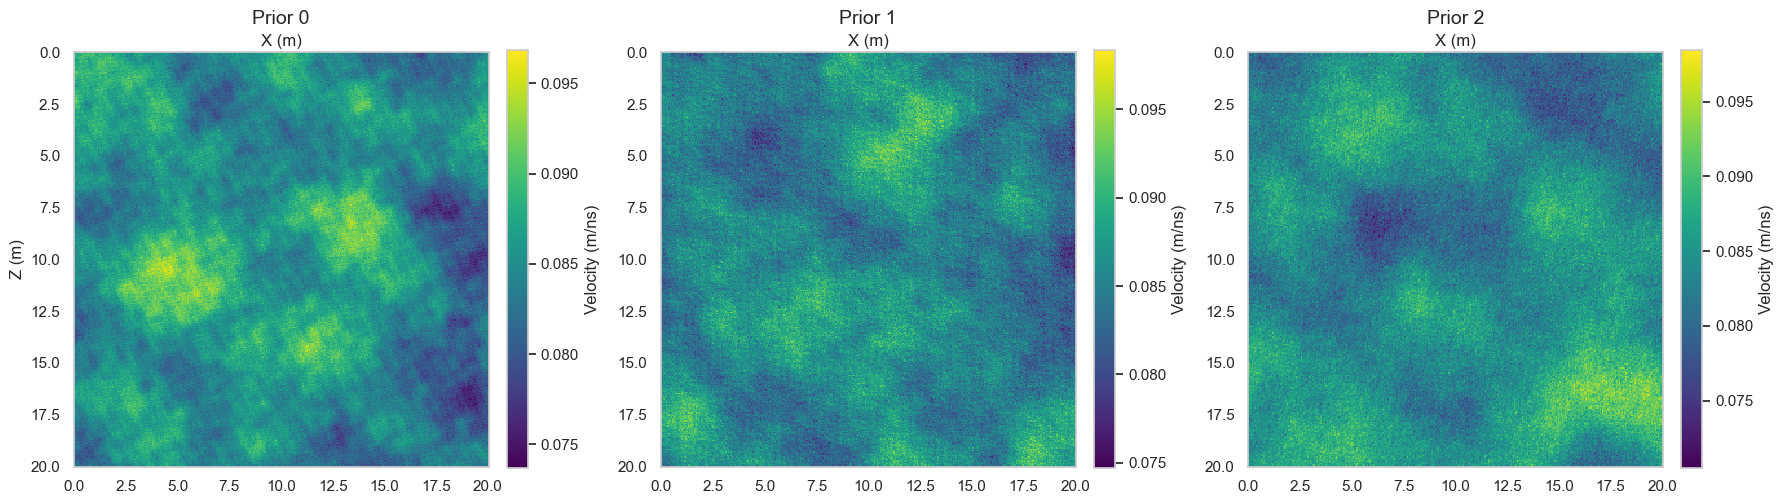

In [ ]:
import matplotlib.pyplot as plt

# Extract spatial coordinates (squeeze removes any extra dimensions from MATLAB format)
x = M_prior['x'].squeeze()
y = M_prior['y'].squeeze()

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

prior_keys = ['prior_0', 'prior_1', 'prior_2']

for i, ax in enumerate(axes):
    # Extract the prior data matrix
    prior_data = M_prior[prior_keys[i]].squeeze()

    # Plot using pcolormesh
    im = ax.pcolormesh(x, y, prior_data, shading='auto', cmap='viridis')

    # Formatting to match standard geophysical depth plots
    ax.set_aspect("equal")
    ax.invert_yaxis() # Usually 'y' represents depth, so we invert it
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Prior {i}", pad=20, fontsize=14)
    ax.set_xlabel("X (m)")

    if i == 0:
        ax.set_ylabel("Z (m)")

    # Add a colorbar for each subplot
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Velocity (m/ns)")

plt.tight_layout()
plt.show()

In [ ]:
M.keys()

dict_keys(['__header__', '__version__', '__globals__', 'sources', 'receivers', 'traveltimes', 'traveltimes_std'])

# Setup prior

The prior is set up by assigning various fields to the prior object. First we assign a name and the type of prior we want to use, let us us the Cholesky method which is based on a cholesky decomposition of the covariance model.

In [ ]:
im = 0
prior = [{}]
prior[im]["name"] = "Cholesky, velocity (m/ns)"
prior[im]["method"] = "cholesky"

prior[im]["x"] = np.arange(min_x - 2 * dx, max_x + 2 * dx, dx)
prior[im]["y"] = np.arange(min_y - 2 * dy, max_y + 2 * dy, dy)
domain_shape = (len(prior[im]["y"]), len(prior[im]["x"]))  # for reshaping later

# Set properties of prior: !dummy values, you need to find the correct values based on the training images!
mean0 = 0.1
h = 8.75
var = 1e-05

prior[im]["m0"] = mean0
prior[im]["Cm"] = "{} Sph({})".format(var, h)


# Setup forward

In [ ]:
# %% SETUP FORWARD
forward = {}
forward["S"] = M["sources"][:, 0:2]
forward["R"] = M["receivers"][:, 0:2]
forward["function"] = "forward_traveltime"


# Setup data

In [ ]:
# %% SETUP DATA
data = [{}]
data[0]["d_obs"] = data_obs
data[0]["d_std"] = data_std


# Test setup

In [ ]:
# %% TEST SETUP
m = pinv.prior.simulate(prior)  # realisations of velocities from prior distribution
d = pinv.forward.forward(m, forward, prior)
logL = pinv.likelihood(d, data)
print("LogL(g(m)) = %6.3f" % (logL[0]))


NameError: name 'pinv' is not defined

## Plot model and rays

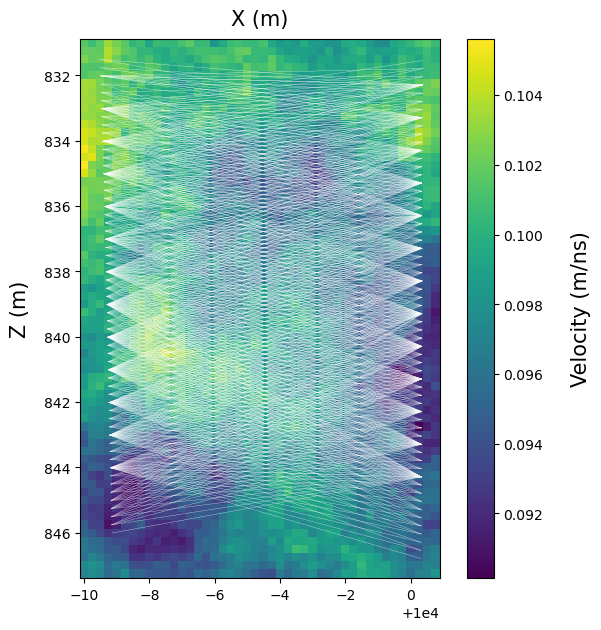

In [ ]:
# %% PLOT MODEL and RAYS
plt.figure(figsize=(7, 7))
plt.pcolor(prior[im]["x"], prior[im]["y"], m[0])
plt.gca().set_aspect("equal")
plt.gca().xaxis.set_label_position("top")
for i in range(ndata):
    plt.plot(
        [sources[i, 0], receivers[i, 0]],
        [sources[i, 1], receivers[i, 1]],
        "w-",
        linewidth=0.2,
    )
plt.gca().invert_yaxis()
plt.xlabel("X (m)", fontsize=15, labelpad=10)
plt.ylabel("Z (m)", fontsize=15, labelpad=10)
cbar = plt.colorbar()
cbar.set_label("Velocity (m/ns)", fontsize=15, labelpad=20)
plt.show()


## Plot data predictions from single forward pass

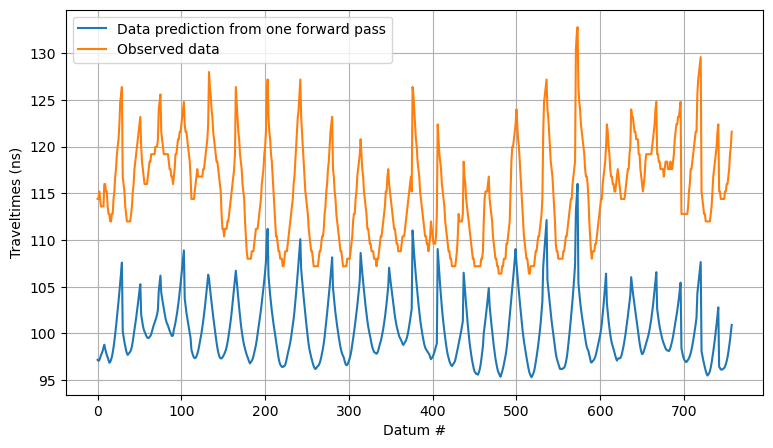

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(d[0], label="Data prediction from one forward pass")
plt.plot(data_obs, label="Observed data")
plt.ylabel("Traveltimes (ns)")
plt.xlabel("Datum #")
plt.legend()
plt.grid("grey")
plt.show()


# Do Metropolis sampling

In [ ]:
# %% SETUP METROPOLIS
mcmc = {}
mcmc["n_ite"] = 1000  # Too short - just for illustration!
# mcmc["n_ite"]=25000 # Longer but still too short?
mcmc["n_sample"] = 100  # number of realizations to store, just for illustration
mcmc["i_plot"] = 100  # plotting option, not working
mcmc["i_progress"] = 50  # how often progress should be updated

# Update step
mcmc["i_update_step"] = 50  # how often step length is adjusted
mcmc["i_update_step_max"] = int(
    mcmc["n_ite"] / 5
)  # for how long will the step length be updated
prior[0]["step_min"] = 0.001  # minimum step length


In [ ]:
pinv.verbose_level = 2  # verbosity level, does not affect model, only print updates

mcmc_out = pinv.sampling.metropolis_chains(
    copy.deepcopy(forward), copy.deepcopy(prior), copy.deepcopy(data), mcmc
)

# Might report error saving stricts using "deepdish" (which copies deep python structures), this is not a problem for this assignment

PINV[-1/1]: metropolis_chains: Starting extended Metropolis sampler jobID=7538
PINV[0/1]: metropolis_chains: Creating 1 chain(s)
PINV[0/1]: Creating chain 0 with T=1.00
PINV[0/1]: Time per iteration 2.891372 s
PINV[0/1]: metropolis: i=    0/ 1000 C00 logL_c=-2.56e+04 [-2.56e+04], AccRate=  0%, T=  1.0, end:12:00:22 Apr-03-2025
PINV[0/1]: metropolis: i=   50/ 1000 C00 logL_c=-2.13e+04 [-2.49e+04], AccRate=  1%, T=  1.0, end:10:39:47 Apr-03-2025
PINV[0/1]: metropolis: i=  100/ 1000 C00 logL_c=-1.57e+04 [-1.57e+04], AccRate=  2%, T=  1.0, end:10:35:00 Apr-03-2025
PINV[0/1]: metropolis: i=  150/ 1000 C00 logL_c=-1.34e+04 [-2.03e+04], AccRate=  4%, T=  1.0, end:10:33:44 Apr-03-2025
PINV[0/1]: metropolis: i=  200/ 1000 C00 logL_c=-1.19e+04 [-1.99e+04], AccRate=  5%, T=  1.0, end:10:36:38 Apr-03-2025
PINV[0/1]: metropolis: i=  250/ 1000 C00 logL_c=-9.4e+03 [-1.53e+04], AccRate=  5%, T=  1.0, end:10:34:49 Apr-03-2025
PINV[0/1]: metropolis: i=  300/ 1000 C00 logL_c=-9.05e+03 [-1.5e+04], AccRate

# Plot results

## Plot log-likelihood

ExtMetChain_20250403_094657.hdf5


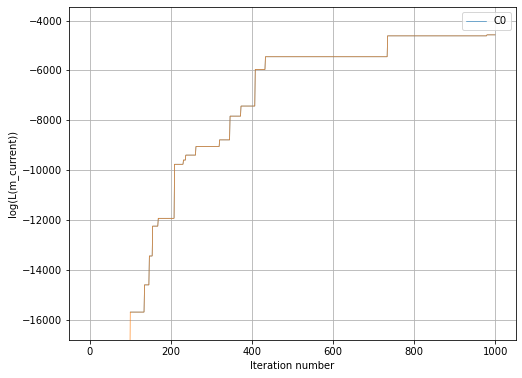

In [ ]:
pinv.plot.plot_likelihood(mcmc_out["hdf5filename"])


## Plot acceptance rate

ExtMetChain_20250403_094657.hdf5


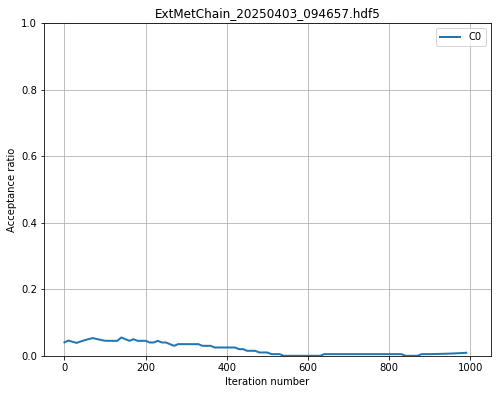

In [ ]:
pinv.plot.plot_acceptance_rate(mcmc_out["hdf5filename"])


## Plot acceptance rate histogram

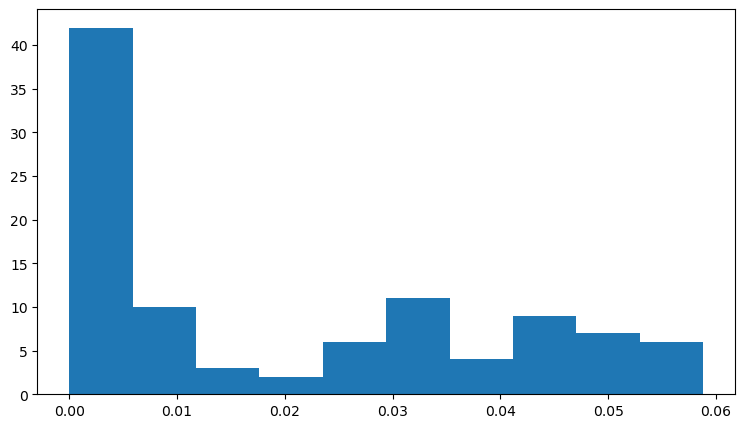

In [ ]:
# The chain is not saved in mcmc variable but stored in hdf5 file
import h5py

f = h5py.File(mcmc_out["hdf5filename"], "r")

# Acc rate is computed as an avg acc rate for a window of maximum 200 indices on each side of the current bin (bins of size 10, "n_ite" = 1000 gives 100 bins)
wi = 100
di = 10
v = "C%d/i_acc" % 0
i_acc = f[v][im, :]

N = len(i_acc)
i_range = np.arange(0, N, di)
accrate = np.zeros(len(i_range))
k = 0
for i in i_range:
    i1 = np.max([0, i - wi])
    i2 = np.min([N, i + wi])
    accrate[k] = np.sum(i_acc[i1:i2]) / (i2 - i1)
    k = k + 1

fig = plt.figure(figsize=(9, 5))
plt.hist(accrate)
plt.show()


## Plot random posterior samples

Trying to read C0/m1 from ExtMetChain_20250403_094657.hdf5


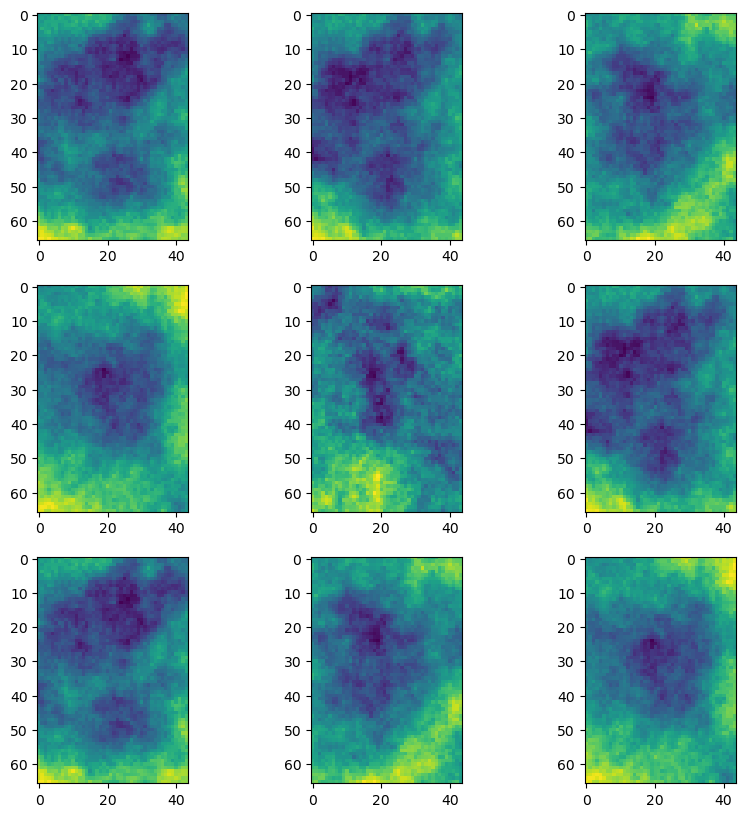

In [ ]:
# Get posterior sample from saved outputs
m_all = pinv.sampling.get_sample_from_hdf5(
    mcmc_out["hdf5filename"], im=0, ic=0, nskip=0
)

# Plot sequence of output models from posterior sample
random_index = np.random.randint(0, 100, 9)
m_plot = m_all[random_index]

fig = plt.figure(figsize=(10, 10))
for i, posterior_sample in enumerate(m_plot):
    ax = fig.add_subplot(3, 3, i + 1)  # this line adds sub-axes
    ax.imshow(posterior_sample.reshape(domain_shape))
plt.show()
